In [1]:
import os
import pandas as pd
import json
import joblib

import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, fbeta_score
import numpy as np

In [2]:
DATA_DIR = os.path.join("..", "data", "processed", "splits")
RESULTS_DIR = os.path.join("..", "data", "processed", "results")

X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_tree.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_tree.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))

In [3]:
base_xgb = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
base_xgb.fit(X_train, y_train.squeeze())

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [4]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.5, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "scale_pos_weight": [1, 2, 5]  # useful if classes are imbalanced
}

xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb.fit(X_train, y_train.squeeze())

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.5, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.3],
                                        'max_depth': [3, 4, 5, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.01, 0.1, 1.0],
                                        'reg_lambda': [0.5, 1.0, 2.0, 5.0],
                                        'scale_pos_weight': [1, 2, 5],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [5]:
best_xgb = xgb.best_estimator_
print("Best Score:", xgb.best_score_)
print("Best Hyperparameters:", xgb.best_params_)

Best Score: 0.9007397612935588
Best Hyperparameters: {'subsample': 0.9, 'scale_pos_weight': 2, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.6}


In [6]:
y_preds_base = base_xgb.predict(X_test)
y_preds = best_xgb.predict(X_test)

print("\n--- Base XGB ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds_base))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
print(classification_report(y_test.squeeze(), y_preds_base))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), base_xgb.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds_base))

print("\n--- Tuned XGB ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds, beta=2))
print(classification_report(y_test.squeeze(), y_preds))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), best_xgb.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds))


--- Base XGB ---
Accuracy: 0.7747252747252747
F2 Score: 0.7613168724279835
              precision    recall  f1-score   support

           0       0.73      0.81      0.77        83
           1       0.82      0.75      0.78        99

    accuracy                           0.77       182
   macro avg       0.78      0.78      0.77       182
weighted avg       0.78      0.77      0.78       182

ROC-AUC: 0.8561518802482657
Confusion Matrix:
 [[67 16]
 [25 74]]

--- Tuned XGB ---
Accuracy: 0.8021978021978022
F2 Score: 0.883495145631068
              precision    recall  f1-score   support

           0       0.87      0.66      0.75        83
           1       0.76      0.92      0.83        99

    accuracy                           0.80       182
   macro avg       0.82      0.79      0.79       182
weighted avg       0.81      0.80      0.80       182

ROC-AUC: 0.8992332968236583
Confusion Matrix:
 [[55 28]
 [ 8 91]]


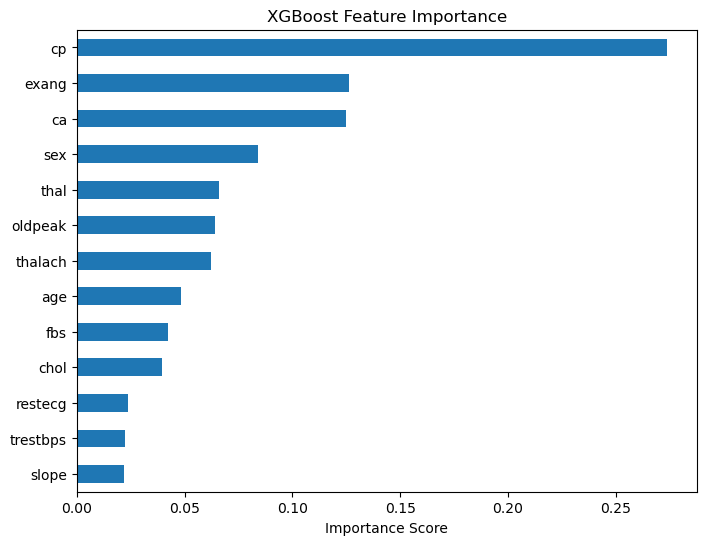

In [7]:
importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.show()

In [8]:
joblib.dump(best_xgb, '../models/xgboost.pkl')

xgb_results = {
    'base_xgb': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds_base)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), base_xgb.predict_proba(X_test)[:, 1])),
        'f2': float(fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
    },
    'tuned_xgb': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), best_xgb.predict_proba(X_test)[:, 1])),
        'f2': float(fbeta_score(y_test.squeeze(), y_preds, beta=2))
    }
}

with open(os.path.join(RESULTS_DIR, 'xgb_results.json'), 'w') as f:
    json.dump(xgb_results, f, indent=4)